# Weather Data Demo

Demonstrates fetching AWH-relevant climate data (RH, temperature, solar irradiance)
for any location in the world using the Open-Meteo API.

**Run the next cell first** so `pandas` and other dependencies are installed into *this* Jupyter kernel (or install once from a terminal: `pip install -e ".[dev]"` using the same Python as your notebook kernel).

In [6]:
# Install this repo + dependencies (pandas, requests, …) into **this** Jupyter kernel.
# Run this once per kernel, or after creating a new venv.
import subprocess
import sys
from pathlib import Path

_repo_root = Path.cwd()
if not (_repo_root / "pyproject.toml").exists():
    _repo_root = _repo_root.parent
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo_root)],
)
print("OK:", _repo_root)

OK: /Users/clara/github-repos/electrolyte_optimization


In [7]:
from src.data.weather import WeatherClient

client = WeatherClient()

## Fetch historical data by coordinates

In [8]:
# Phoenix, AZ — a hot/arid test case
df = client.get_historical(
    latitude=33.45,
    longitude=-112.07,
    start='2023-06-01',
    end='2023-06-30',
)
df.head()

,temperature_2m,relative_humidity_2m,shortwave_radiation,direct_normal_irradiance,diffuse_radiation,terrestrial_radiation,wind_speed_10m,precipitation,surface_pressure,et0_fao_evapotranspiration,latitude,longitude
time,,,,,,,,,,,,
2023-06-01 00:00:00-07:00,23.0,25,0.0,0.0,0.0,0.0,5.6,0.0,968.3,0.06,33.427063,-112.02719
2023-06-01 01:00:00-07:00,22.1,26,0.0,0.0,0.0,0.0,6.8,0.0,968.2,0.07,33.427063,-112.02719
2023-06-01 02:00:00-07:00,21.1,28,0.0,0.0,0.0,0.0,7.6,0.0,968.5,0.08,33.427063,-112.02719
2023-06-01 03:00:00-07:00,21.4,27,0.0,0.0,0.0,0.0,3.4,0.0,968.9,0.03,33.427063,-112.02719
2023-06-01 04:00:00-07:00,18.5,35,0.0,0.0,0.0,0.0,6.3,0.0,969.3,0.05,33.427063,-112.02719


## Fetch historical data by place name

In [9]:
# High-humidity tropical site
df_singapore = client.get_historical_by_name(
    'Singapore',
    start='2023-01-01',
    end='2023-12-31',
)
print(df_singapore['location_name'].iloc[0])
df_singapore[['temperature_2m', 'relative_humidity_2m', 'shortwave_radiation']].describe()

Temasek, Singapore


,temperature_2m,relative_humidity_2m,shortwave_radiation
count,8760.000000,8760.000000,8760.000000
mean,27.282374,82.468493,218.130936
std,1.926775,9.074197,292.415038
min,22.400000,46.000000,0.000000
25%,25.775000,77.000000,0.000000
50%,27.200000,84.000000,5.500000
75%,28.600000,89.000000,441.000000
max,33.500000,100.000000,987.000000


## Compare AWH potential across sites

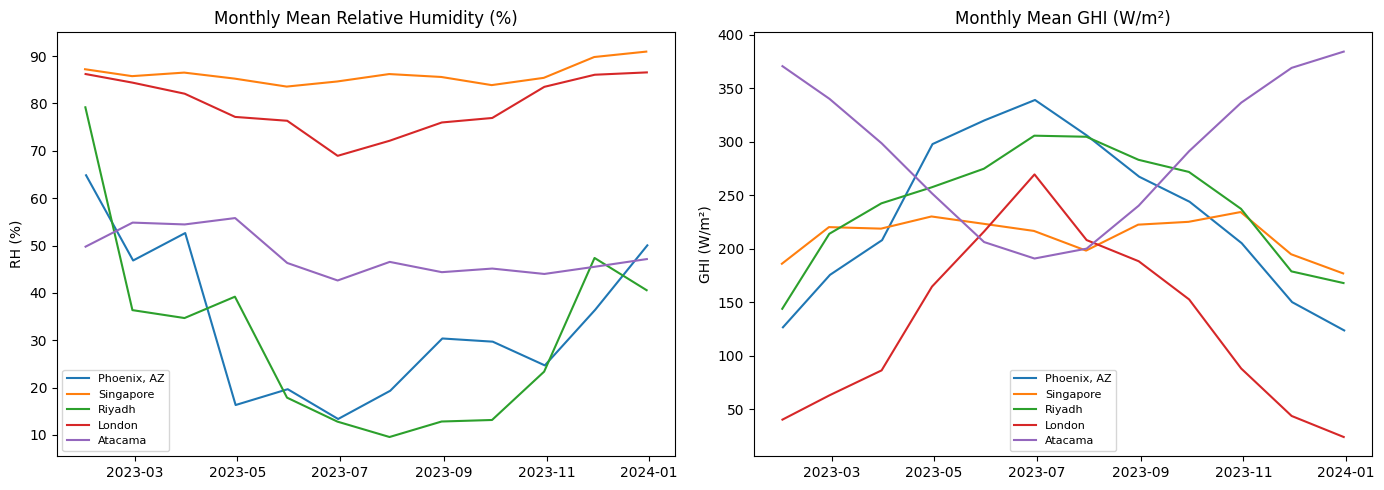

In [10]:
import matplotlib.pyplot as plt

sites = {
    'Phoenix, AZ': (33.45, -112.07),
    'Singapore':   (1.35,   103.82),
    'Riyadh':      (24.69,   46.72),
    'London':      (51.51,   -0.13),
    'Atacama':     (-23.87, -69.85),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (lat, lon) in sites.items():
    d = client.get_historical(lat, lon, '2023-01-01', '2023-12-31')
    monthly = d[['relative_humidity_2m', 'shortwave_radiation']].resample('ME').mean()
    axes[0].plot(monthly.index, monthly['relative_humidity_2m'], label=name)
    axes[1].plot(monthly.index, monthly['shortwave_radiation'], label=name)

axes[0].set_title('Monthly Mean Relative Humidity (%)')
axes[0].set_ylabel('RH (%)')
axes[0].legend(fontsize=8)

axes[1].set_title('Monthly Mean GHI (W/m²)')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Monthly climate summary

In [11]:
summary = client.get_climate_summary(
    latitude=33.45, longitude=-112.07,
    start='2023-01-01', end='2023-12-31',
    freq='ME'
)
# Show mean RH and GHI by month
summary[['relative_humidity_2m', 'shortwave_radiation']].xs('mean', axis=1, level=1)

,relative_humidity_2m,shortwave_radiation
time,,
2023-01-31 00:00:00-07:00,64.830645,126.454301
2023-02-28 00:00:00-07:00,46.836310,175.480655
2023-03-31 00:00:00-07:00,52.631720,207.940860
2023-04-30 00:00:00-07:00,16.316667,297.731944
2023-05-31 00:00:00-07:00,19.658602,319.979839
2023-06-30 00:00:00-07:00,13.368056,338.965278
2023-07-31 00:00:00-07:00,19.329301,305.598118
2023-08-31 00:00:00-07:00,30.368280,267.220430
2023-09-30 00:00:00-07:00,29.695833,243.805556
